In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [3]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [4]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [5]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [6]:
portfolio.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [7]:
# Calculate daily returns
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

returns = nav.dropna(subset=["daily_return"])

In [8]:
var_cvar = []

for code, grp in returns.groupby("amfi_code"):

    var95 = np.percentile(grp["daily_return"],5)

    cvar95 = grp.loc[
        grp["daily_return"]<=var95,
        "daily_return"
    ].mean()

    var_cvar.append({
        "amfi_code":code,
        "VaR_95":var95,
        "CVaR_95":cvar95
    })

var_cvar = pd.DataFrame(var_cvar)

var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [9]:
var_cvar.to_csv("../reports/var_cvar_report.csv",index=False)

In [10]:
returns["rolling_mean"] = (
    returns.groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).mean())
)

returns["rolling_std"] = (
    returns.groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).std())
)

returns["rolling_sharpe"] = (
    returns["rolling_mean"] /
    returns["rolling_std"]
) * np.sqrt(252)

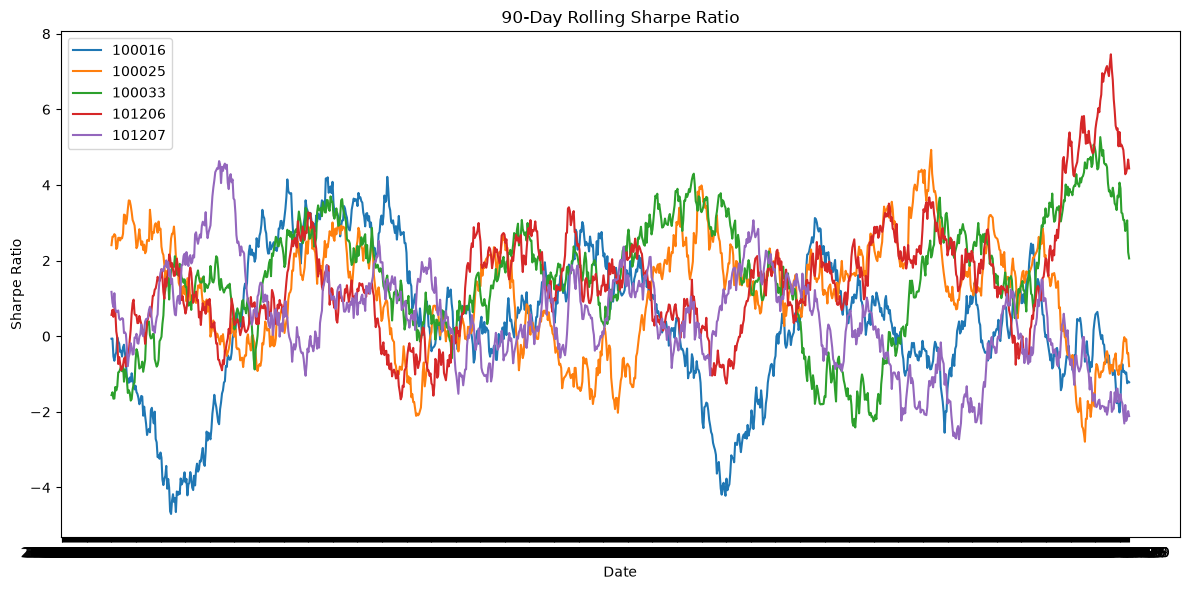

In [11]:
import matplotlib.pyplot as plt

# Select first 5 funds
top5 = returns["amfi_code"].unique()[:5]

plt.figure(figsize=(12,6))

for code in top5:
    data = returns[returns["amfi_code"] == code]
    plt.plot(
        data["date"],
        data["rolling_sharpe"],
        label=str(code)
    )

plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()

plt.tight_layout()

plt.savefig("../reports/rolling_sharpe_chart.png")

plt.show()

In [12]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions["cohort_year"] = (
    transactions["transaction_date"].dt.year
)

cohort = (
    transactions
    .groupby("cohort_year")
    .agg(
        avg_sip=("amount_inr","mean"),
        total_invested=("amount_inr","sum"),
        investors=("investor_id","nunique")
    )
    .reset_index()
)

cohort

,cohort_year,avg_sip,total_invested,investors
0,2024,107739.476605,2500633252,4803
1,2025,106704.345527,1020947178,4018


In [13]:
# Count investments by cohort year and fund
fund_pref = (
    transactions
    .groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="investment_count")
)

# Find the most preferred fund for each cohort
top_fund = (
    fund_pref.sort_values(
        ["cohort_year", "investment_count"],
        ascending=[True, False]
    )
    .groupby("cohort_year")
    .first()
    .reset_index()
)

top_fund

,cohort_year,amfi_code,investment_count
0,2024,119094,625
1,2025,119551,271


In [14]:
top_fund.to_csv(
    "../reports/cohort_top_funds.csv",
    index=False
)

In [15]:
transactions = transactions.sort_values(
    ["investor_id", "transaction_date"]
)

transactions["gap_days"] = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

In [16]:
at_risk = transactions[transactions["gap_days"] > 35]

at_risk.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
24079,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2025,71.0
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,2024,107.0
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,69.0
24661,INV000002,2025-01-23,118632,Lumpsum,317170,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2025,112.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2025,114.0


In [17]:
at_risk.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)